In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Truncation and Round-off Errors
1. **Truncation Errors** occur when an infinite continuous process is approximated by a finite discrete process, such as the discretization of differential equations into difference equations. For instance, when deriving the Euler method for integration, we make the following approximation:
$$\frac{dy}{dt}=f(y,t) \implies \frac{y_{n+1}-y_n}{h}=f(y_n,t_n)$$
This approximation comes from truncating the Taylor expansion of the the equation at the first order term by assuming that $h$ is small. Hence, these errors can be minimized by choosing smaller step sizes $h$ (i.e. taking a larger number of steps).

2. **Round-off Errors** originate from the finite precision of floating-point arithmetic in computers, which can accumulate and blow up for certain iterative processes. For instance, when we run the operation $1+10^{-16}$ on a 64-bit system, the answer returned is 1.0 instead of 1.0000000000000001, since the computer is unable to store that degree of precision in float-point representation. Rounding errors occur at every computation and will tend to snowball for a large the number of steps. Hence, these errors are minimized by limiting the total number of steps (i.e. taking larger steps $h$).

## Error Optimization
The minimization of both truncation errors and round-off errors is a tradeoff, since excessively small step sizes will require a large number of steps, causing round-off errors to blow up, whereas large step sizes will lower precision due to truncation. Hence, the step size $h$ must be optimized to minimize both errors. 

This can be done by one of the following methods:

1. Investigating the threshold size of $h$ at which round-off errors dominate over truncation errors and staying just below that limit. 
2. Choosing an alternate algorithm that is less sensitive to truncation errors. For example, the Euler method has truncation error $\mathcal{O}(h^2)$ whereas the Runge-Kutta (RK4) method has truncation error $\mathcal{O}(h^5)$, which means that we can choose larger values of $h$ and get the same degree of precision in fewer steps, and therefore lower round-off error.
3. Using adaptive step size algorithms that adjust the step size based on how rapidly the function changes locally. Hence, if a function changes smoothly, it can be approximated by larger step sizes, whereas abrupt changes in the slope require smaller step sizes. This allows for reduced computations in regions that do not require a high degree of precision, thereby minimizing roundoff errors, while keeping truncation errors in check for more complex regions. 

# Integration Algorithm Stability 
The method of finite difference can either use the explicit or implicit approach. For a differential equation of the form $dy/dt=f(y,t)$, the update functions are: 
1. Explicit Method: $y_{n+1}=y_n + hf(y_n, t_n)$
2. Implicit Method: $y_{n+1}=y_n + hf(y_{n+1}, t_{n+1})$

If $f(y,t)=-0.5*y$, the explicit form is $y_{n+1}=y_n-0.5*hy_n$ and the implicit form is $y_{n+1}=(y_n)/(1+0.5*h)$. We can see their behaviour below: 

In [2]:
# Exact solution
def exact(t):
    return np.exp(-0.5*t)

# Explicit Method
def explicit(h, T):
    N = int(T/h)
    t = np.linspace(0, T, N+1)
    y = np.zeros(N+1)
    y[0] = 1
    for n in range(N):
        y[n+1] = y[n] - 0.5*h*y[n]
    return t, y

# Implicit Method
def implicit(h, T):
    N = int(T/h)
    t = np.linspace(0, T, N+1)
    y = np.zeros(N+1)
    y[0] = 1
    for n in range(N):
        y[n+1] = y[n]/(1 + 0.5*h)
    return t, y

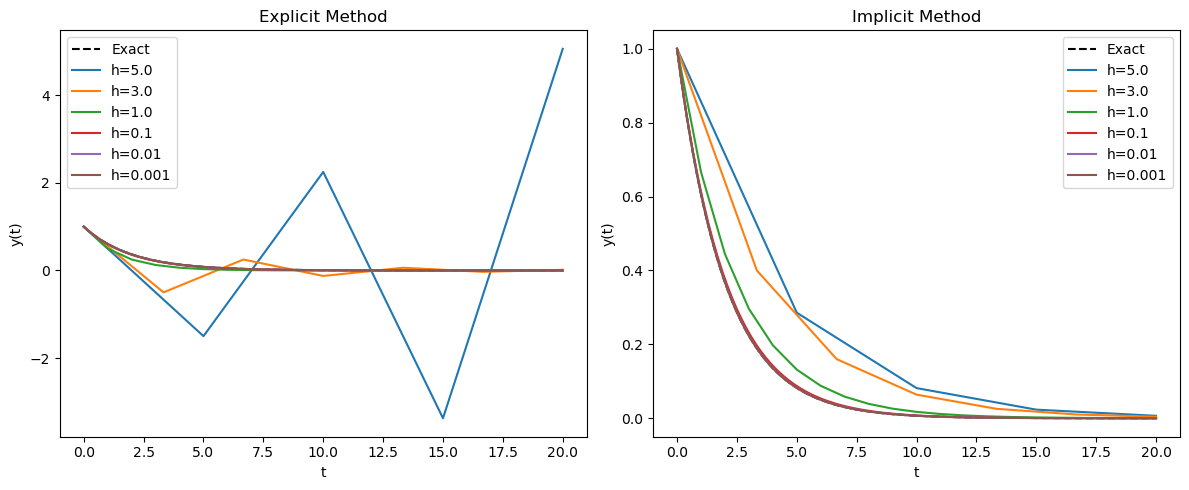

In [3]:
H = np.array([5, 3, 1, 0.1, 0.01, 0.001])
T = 20

t_exact = np.linspace(0, T, 1000)
y_exact = exact(t_exact)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_exact, y_exact, "k--", label="Exact")
for h in H:
    t, y = explicit(h, T)
    plt.plot(t, y, label=f"h={h}")
plt.title("Explicit Method")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_exact, y_exact, "k--", label="Exact")
for h in H:
    t, y = implicit(h, T)
    plt.plot(t, y, label=f"h={h}")
plt.title("Implicit Method")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()

plt.tight_layout()
plt.show()

The stability of the explicit method is sensitive to the step size $h$. We can find the convergence condition: 
$$\bigg|\frac{y_{n+1}}{y_n}\bigg|=|(1-0.5*h)|\leq 1 \implies h\leq 4$$
Hence, if $h\geq4$ the solution will diverge in the explicit scheme. However, the implicit method is robust even for large step sizes, giving us reasonable estimates even for 2 step integration. The actual error of each method is plotted against the step size below.

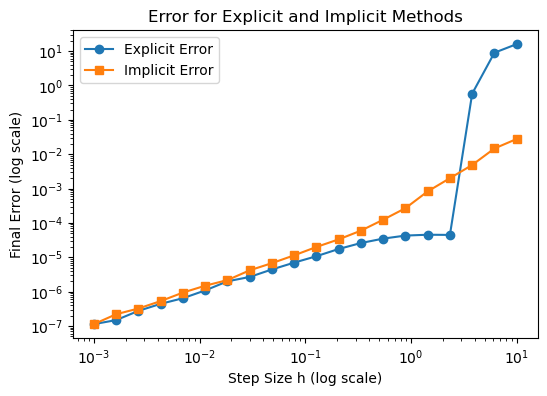

In [4]:
H = np.logspace(-3, 1, 20)
T = 20
exp_err = []
imp_err = []

for h in H:
    t_exp, y_exp = explicit(h, T)
    exp_err.append(np.abs(y_exp[-1] - exact(t_exp[-1])))
    t_imp, y_imp = implicit(h, T)
    imp_err.append(np.abs(y_imp[-1] - exact(t_imp[-1])))

plt.figure(figsize=(6,4))
plt.loglog(H, exp_err, "o-", label="Explicit Error")
plt.loglog(H, imp_err, "s-", label="Implicit Error")
plt.title("Error for Explicit and Implicit Methods")
plt.xlabel("Step Size h (log scale)")
plt.ylabel("Final Error (log scale)")
plt.legend()
plt.show()

For large step sizes, we find that the implicit method maintains stability and gives us lower final deviation from the analytical solution.